# Entrenamiento de modelos de Machine Learning

En este notebook se entrenan diferentes modelos de Machine Learning para predecir la diferencia de goles entre dos selecciones nacionales.

Se comparará el rendimiento de distintos algoritmos de regresión utilizando métricas estándar de evaluación.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [98]:
dataset = pd.read_csv("../data/processed/dataset_modelado.csv")

In [99]:
dataset.shape

(16704, 30)

In [1]:
dataset.head()

NameError: name 'dataset' is not defined

## Selección de variables predictoras

Se seleccionan únicamente variables disponibles antes del partido.

Se excluyen variables que contienen información del resultado final para evitar fuga de información.

In [101]:
dataset.columns.tolist()

['date',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'tournament',
 'neutral',
 'goal_diff',
 'tournament_weight',
 'fifa_rank_home',
 'fifa_points_home',
 'fifa_rank_away',
 'fifa_points_away',
 'elo_home',
 'elo_away',
 'fifa_rank_diff',
 'fifa_points_diff',
 'elo_diff',
 'home_last5_points',
 'home_last5_goals_for',
 'home_last5_goals_against',
 'home_last5_goal_balance',
 'away_last5_points',
 'away_last5_goals_for',
 'away_last5_goals_against',
 'away_last5_goal_balance',
 'form_points_diff',
 'form_goals_for_diff',
 'form_goals_against_diff',
 'form_goal_balance_diff']

In [102]:
features = [

    "neutral",
    "tournament_weight",

    "fifa_rank_diff",
    "fifa_points_diff",

    "elo_diff",

    "form_points_diff",
    "form_goals_for_diff",
    "form_goals_against_diff",
    "form_goal_balance_diff"

]

In [103]:
target = "goal_diff"

## Construcción de variables predictoras y objetivo

In [104]:
X = dataset[features]

y = dataset[target]

In [105]:
X.head()

,neutral,tournament_weight,fifa_rank_diff,fifa_points_diff,elo_diff,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
0,0,6,-68.0,-270.0,-372.0,-4.0,-8.0,-6.0,-2.0
1,0,6,-52.0,-216.0,-309.0,-4.0,-3.0,-12.0,9.0
2,0,6,3.0,14.0,479.0,-3.0,-4.0,-6.0,2.0
3,0,1,-27.0,-112.0,-183.0,-5.0,-5.0,-4.0,-1.0
4,0,3,126.0,429.0,490.0,2.0,2.0,-3.0,5.0


In [106]:
y.head()

0    0.0
1   -2.0
2    9.0
3    0.0
4    3.0
Name: goal_diff, dtype: float64

In [107]:
print(X.shape)
print(y.shape)

(16704, 9)
(16704,)


## División de entrenamiento y prueba

Se reserva un 20% de los partidos para evaluación final.

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [109]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(13363, 9)
(3341, 9)
(13363,)
(3341,)


## Escalado de variables

Las variables se normalizan para facilitar el entrenamiento de modelos sensibles a la escala.

In [110]:
scaler = StandardScaler()

In [111]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [112]:
X_train_scaled[:5]

array([[-0.6003155 ,  0.77514872, -1.79949545, -1.50747305, -1.63433645,
        -1.51960669, -1.35117973,  0.10670765, -0.89644525],
       [-0.6003155 ,  0.77514872, -1.02933346, -0.54133706, -0.97326192,
         0.46306312,  0.724082  ,  1.28907445, -0.38799573],
       [-0.6003155 , -0.01538111,  0.18092109,  0.08155336,  0.35943621,
        -0.63842011, -0.93612738,  0.69789105, -1.02355763],
       [-0.6003155 , -1.20117585,  0.9144087 ,  0.71772559,  0.85875846,
         1.12395306,  2.59181756, -0.28741461,  1.77291474],
       [-0.6003155 , -1.20117585,  1.00609465,  0.73067701,  0.83062763,
        -1.51960669, -0.72860121,  0.89495219, -1.02355763]])

In [113]:
#import joblib

#joblib.dump(
 #   scaler,
  #  "scaler.pkl"
#)

## Regresión Lineal

Se entrena un modelo de regresión lineal utilizando las variables seleccionadas.

Este modelo servirá como referencia base para comparar posteriormente con modelos más complejos.

In [114]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [115]:
y_pred_lr = lr.predict(
    X_test_scaled
)

### Evaluación del modelo

Se calculan las métricas:

- MAE (Error Absoluto Medio)
- RMSE (Raíz del Error Cuadrático Medio)
- R²

In [116]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

MAE:  1.2642
RMSE: 1.6435
R²:   0.3745


In [117]:
coeficientes_lr = pd.DataFrame({
    "Variable": features,
    "Coeficiente": lr.coef_
})

coeficientes_lr.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
4,elo_diff,1.159599
2,fifa_rank_diff,0.149985
8,form_goal_balance_diff,0.104113
6,form_goals_for_diff,0.022834
1,tournament_weight,0.020939
3,fifa_points_diff,-0.104610
5,form_points_diff,-0.110653
7,form_goals_against_diff,-0.139722
0,neutral,-0.208929


In [118]:
coeficientes_lr["Importancia"] = (
    coeficientes_lr["Coeficiente"]
    .abs()
)

coeficientes_lr.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Coeficiente,Importancia
4,elo_diff,1.159599,1.159599
0,neutral,-0.208929,0.208929
2,fifa_rank_diff,0.149985,0.149985
7,form_goals_against_diff,-0.139722,0.139722
5,form_points_diff,-0.110653,0.110653
3,fifa_points_diff,-0.104610,0.104610
8,form_goal_balance_diff,0.104113,0.104113
6,form_goals_for_diff,0.022834,0.022834
1,tournament_weight,0.020939,0.020939


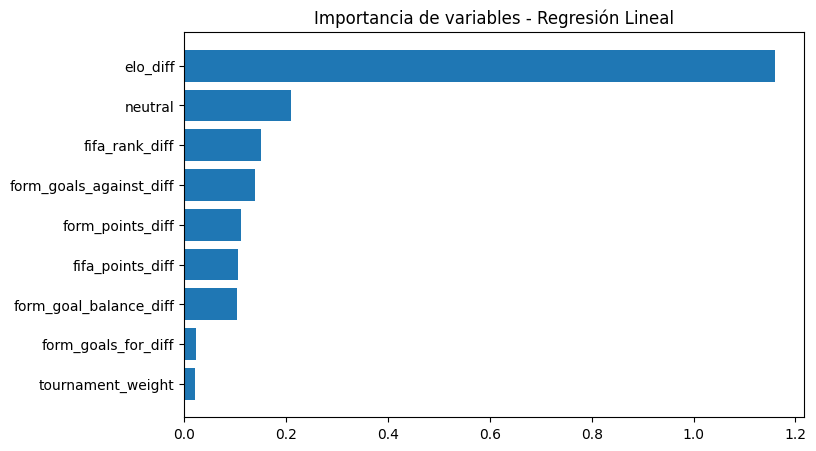

In [119]:
coeficientes_lr = coeficientes_lr.sort_values(
    by="Importancia"
)

plt.figure(figsize=(8,5))

plt.barh(
    coeficientes_lr["Variable"],
    coeficientes_lr["Importancia"]
)

plt.title(
    "Importancia de variables - Regresión Lineal"
)

plt.show()

## Random Forest Regressor

Se entrena un modelo basado en árboles de decisión para capturar relaciones no lineales entre las variables.

In [120]:
from sklearn.ensemble import RandomForestRegressor

In [121]:
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [122]:
y_pred_rf = rf.predict(X_test)

In [123]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

MAE:  1.2655
RMSE: 1.6537
R²:   0.3668


In [124]:
importancias_rf = pd.DataFrame({
    "Variable": features,
    "Importancia": rf.feature_importances_
})

importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
4,elo_diff,0.927061
0,neutral,0.018967
7,form_goals_against_diff,0.013251
2,fifa_rank_diff,0.011743
8,form_goal_balance_diff,0.011323
3,fifa_points_diff,0.010018
6,form_goals_for_diff,0.003241
5,form_points_diff,0.002842
1,tournament_weight,0.001555


Se entrenó un modelo Random Forest Regressor para capturar posibles relaciones no lineales entre las variables explicativas. Sin embargo, los resultados obtenidos fueron ligeramente inferiores a los de la regresión lineal, obteniendo un R² de 0.353 frente al 0.375 de la regresión lineal. Esto sugiere que la relación entre las variables seleccionadas y la diferencia de goles presenta un comportamiento predominantemente lineal.

## Comparación de modelos

In [125]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})

comparacion

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,1.264191,1.643545,0.374535
1,Random Forest,1.265467,1.653698,0.366783


## XGBoost Regressor

Se entrena un modelo basado en Gradient Boosting optimizado, ampliamente utilizado en problemas de Machine Learning sobre datos tabulares.

In [70]:
from sklearn.ensemble import GradientBoostingRegressor

In [71]:
from xgboost import XGBRegressor

In [140]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=4,
    random_state=42
)

In [141]:
xgb.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [142]:
y_pred_xgb = xgb.predict(X_test)

In [143]:
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")

MAE:  1.2632
RMSE: 1.6536
R²:   0.3668


In [76]:
importancias_xgb = pd.DataFrame({
    "Variable": features,
    "Importancia": xgb.feature_importances_
})

importancias_xgb.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
4,elo_diff,0.686204
0,neutral,0.077635
8,form_goal_balance_diff,0.043739
2,fifa_rank_diff,0.040598
7,form_goals_against_diff,0.038783
3,fifa_points_diff,0.033155
1,tournament_weight,0.031763
5,form_points_diff,0.025063
6,form_goals_for_diff,0.023060


# KNN Regressor

In [77]:
from sklearn.neighbors import KNeighborsRegressor

In [78]:
knn = KNeighborsRegressor(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [79]:
y_pred_knn = knn.predict(
    X_test_scaled
)

In [80]:
mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

print(f"MAE:  {mae_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"R²:   {r2_knn:.4f}")

MAE:  1.3940
RMSE: 1.8017
R²:   0.2484


In [81]:
resultados_knn = []

for k in range(3, 21):

    knn = KNeighborsRegressor(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    pred = knn.predict(
        X_test_scaled
    )

    r2 = r2_score(
        y_test,
        pred
    )

    resultados_knn.append(
        [k, r2]
    )

resultados_knn = pd.DataFrame(
    resultados_knn,
    columns=["K", "R2"]
)

resultados_knn.sort_values(
    by="R2",
    ascending=False
).head(10)

,K,R2
17,20,0.338145
15,18,0.337409
14,17,0.335981
16,19,0.335735
13,16,0.332370
12,15,0.330038
11,14,0.328648
10,13,0.327928
9,12,0.322283
8,11,0.318331


# SVR

In [82]:
from sklearn.svm import SVR

In [83]:
svr = SVR(
    kernel="rbf",
    C=1.0,
    epsilon=0.1
)

svr.fit(
    X_train_scaled,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [84]:
y_pred_svr = svr.predict(
    X_test_scaled
)

In [85]:
mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

rmse_svr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

print(f"MAE: {mae_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"R²: {r2_svr:.4f}")

MAE: 1.2658
RMSE: 1.6655
R²: 0.3577


# 6. Árbol de Decisión

Se entrena un modelo Decision Tree Regressor para predecir la diferencia de goles utilizando las variables seleccionadas.

In [86]:
from sklearn.tree import DecisionTreeRegressor

In [87]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [88]:
y_pred_dt = dt.predict(
    X_test
)

In [89]:
mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dt
    )
)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print(f"MAE: {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R²: {r2_dt:.4f}")

MAE: 1.8345
RMSE: 2.4148
R²: -0.3503


In [90]:
importancias_dt = pd.DataFrame({
    "Variable": features,
    "Importancia": dt.feature_importances_
})

importancias_dt.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
4,elo_diff,0.478999
3,fifa_points_diff,0.135870
2,fifa_rank_diff,0.101145
6,form_goals_for_diff,0.063250
8,form_goal_balance_diff,0.062669
7,form_goals_against_diff,0.062128
5,form_points_diff,0.058067
1,tournament_weight,0.026326
0,neutral,0.011547


# 7. Ridge Regression

Se entrena un modelo Ridge para analizar si la regularización mejora el rendimiento de la regresión lineal.

In [91]:
from sklearn.linear_model import Ridge

In [92]:
ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [93]:
y_pred_ridge = ridge.predict(
    X_test_scaled
)

In [94]:
mae_ridge = mean_absolute_error(
    y_test,
    y_pred_ridge
)

rmse_ridge = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print(f"MAE: {mae_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R²: {r2_ridge:.4f}")

MAE: 1.2642
RMSE: 1.6435
R²: 0.3745


In [95]:
coeficientes_ridge = pd.DataFrame({
    "Variable": features,
    "Coeficiente": ridge.coef_
})

coeficientes_ridge["Importancia"] = (
    coeficientes_ridge["Coeficiente"]
    .abs()
)

coeficientes_ridge.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Coeficiente,Importancia
4,elo_diff,1.159200,1.159200
0,neutral,-0.208914,0.208914
2,fifa_rank_diff,0.150170,0.150170
7,form_goals_against_diff,-0.139734,0.139734
5,form_points_diff,-0.110645,0.110645
3,fifa_points_diff,-0.104453,0.104453
8,form_goal_balance_diff,0.104124,0.104124
6,form_goals_for_diff,0.022841,0.022841
1,tournament_weight,0.020940,0.020940


In [126]:
from sklearn.model_selection import GridSearchCV

In [139]:
param_grid = {

    "n_estimators":[100,300,500,700],

    "max_depth":[2,3,4,5,6],

    "learning_rate":[0.005,0.01,0.05,0.1],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0]

}

In [145]:
grid_xgb = GridSearchCV(

    estimator=XGBRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1

)

In [146]:
grid_xgb.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [147]:
print(grid_xgb.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}


In [148]:
xgb_opt = XGBRegressor(
    n_estimators=500,
    learning_rate=0.005,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42
)

xgb_opt.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [149]:
pred_xgb_opt = xgb_opt.predict(X_test)

In [150]:
mae_xgb_opt = mean_absolute_error(y_test, pred_xgb_opt)

rmse_xgb_opt = np.sqrt(
    mean_squared_error(y_test, pred_xgb_opt)
)

r2_xgb_opt = r2_score(
    y_test,
    pred_xgb_opt
)

In [151]:
print("MAE:", mae_xgb_opt)
print("RMSE:", rmse_xgb_opt)
print("R2:", r2_xgb_opt)

MAE: 1.2609158993637362
RMSE: 1.6538107622702989
R2: 0.36669682894223155


In [131]:
print(grid_xgb.best_score_)

-1.253859688452526


In [132]:
best_xgb = grid_xgb.best_estimator_

In [133]:
param_grid_rf = {

    "n_estimators":[100,300,500],

    "max_depth":[3,5,10,None],

    "min_samples_split":[2,5,10]

}

In [ ]:
param_grid_rf = {

    "n_estimators":[100,300,500,800],

    "max_depth":[3,5,8,10,15,None],

    "min_samples_split":[2,5,10,15],

    "min_samples_leaf":[1,2,4,8],

    "max_features":[
        "sqrt",
        "log2",
        None
    ]
}

In [134]:
grid_rf = GridSearchCV(

    RandomForestRegressor(
        random_state=42
    ),

    param_grid_rf,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1

)

In [136]:
grid_rf.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [137]:
print(grid_rf.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
print("MAE:", mae_xgb_opt)
print("RMSE:", rmse_xgb_opt)
print("R2:", r2_xgb_opt)

In [154]:
resultados = pd.DataFrame({

    "Modelo":[
        "Linear Regression",
        "Ridge",
        "SVR",
        "Random Forest",
        "XGBoost",
        "KNN",
        "Decision Tree",
        "xgb_opt"

    ],

    "MAE":[
        mae_lr,
        mae_ridge,
        mae_svr,
        mae_rf,
        mae_xgb,
        mae_knn,
        mae_dt,
        mae_xgb_opt
    ],

    "RMSE":[
        rmse_lr,
        rmse_ridge,
        rmse_svr,
        rmse_rf,
        rmse_xgb,
        rmse_knn,
        rmse_dt,
        rmse_xgb_opt
    ],

    "R2":[
        r2_lr,
        r2_ridge,
        r2_svr,
        r2_rf,
        r2_xgb,
        r2_knn,
        r2_dt,
        r2_xgb_opt
    ]
})

resultados.sort_values(
    by="R2",
    ascending=False
)

,Modelo,MAE,RMSE,R2
1,Ridge,1.264186,1.643540,0.374538
0,Linear Regression,1.264191,1.643545,0.374535
4,XGBoost,1.263167,1.653618,0.366844
3,Random Forest,1.265467,1.653698,0.366783
7,xgb_opt,1.260916,1.653811,0.366697
2,SVR,1.265781,1.665462,0.357742
5,KNN,1.394014,1.801715,0.248356
6,Decision Tree,1.834481,2.414847,-0.350266


mas de n= 300, grisser

In [99]:
resultados.to_csv(
    "comparacion_modelos.csv",
    index=False
)

In [102]:
import joblib

joblib.dump(
    lr,
    "modelo_regresion_lineal.pkl"
)

['modelo_regresion_lineal.pkl']

In [104]:
joblib.dump(
    ridge,
    "modelo_ridge.pkl"
)

['modelo_ridge.pkl']